# Complete target interfaces and minimal obstructions

This notebook enumerates every target subset in each frozen contract, independently reconstructs the Druid triple, and reruns the abstract construction checks. It uses compact moments and the original simultaneous events. No new battles or error allocation are introduced.

The paper's 128 registered targets and the 16,384 base-menu target subsets have different denominators. Base, expansion, task-projection and tolerance strata remain separate.


In [1]:
from pathlib import Path
import sys

roots = (Path.cwd(), *Path.cwd().parents)
ROOT = next((p for p in roots if (p / "pyproject.toml").is_file() and (p / "src/wowfs").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Run this notebook from the repository or one of its subdirectories.")
sys.path.insert(0, str(ROOT / "src"))
from wowfs.reproduction.context import get_context
ctx = get_context()

import json
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
FIGURES = ctx.output / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

def table(rows, columns):
    text = "| " + " | ".join(columns) + " |\n| " + " | ".join(["---"] * len(columns)) + " |\n"
    for row in rows:
        text += "| " + " | ".join(str(row.get(k, "")) for k in columns) + " |\n"
    display(Markdown(text))

print("Input bundle:", ctx.bundle)
print("Generated outputs:", ctx.output)


Input bundle: /work/Users/leiyo/wow-forever-sustainability-work/inputs/paper-reproduction/review/review-v2
Generated outputs: /work/Users/leiyo/wow-forever-sustainability-work/artifacts/paper-reproduction/code-only-rendered-20260928


In [2]:
from wowfs.reproduction.science import run_interface_checks

result = run_interface_checks(ctx, resume=True)
assert result["status"] == "PASS"
summary = result["native"]
print(json.dumps({k: summary[k] for k in ("contracts", "total_target_queries", "strata", "projection_merge_count")}, indent=2))


{
  "contracts": 96,
  "total_target_queries": 184320,
  "strata": {
    "primary_base": 16,
    "primary_expanded": 8,
    "frozen_task_projection": 8,
    "frozen_secondary_tolerance": 64
  },
  "projection_merge_count": 0
}


## Low-order information misses full-target failures

A certified miss at order $r$ is a full target with status NO whose every subset of size at most $r$ is YES. A low-order UNKNOWN blocks certification. Exact finite-mean counts and simultaneous-event certified counts are shown separately.


| order | certified_false_positive_count | exact_false_positive_count | unknown_blocked_cases |
| --- | --- | --- | --- |
| 1 | 351 | 403 | 974 |
| 2 | 3 | 9 | 4 |
| 3 | 0 | 0 | 0 |


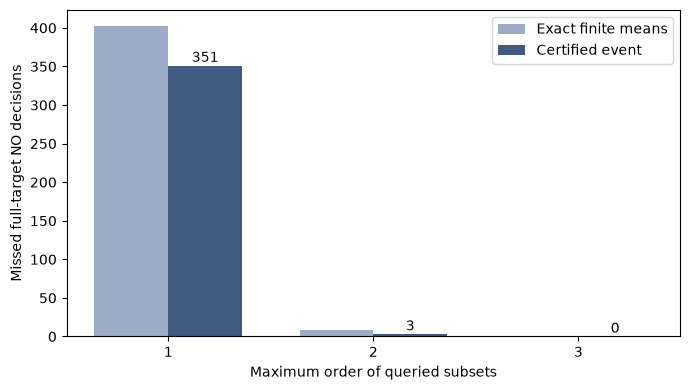

In [3]:
base = summary["strata_summaries"]["primary_base"]
low_order = [{"order": int(order), **row} for order, row in base["low_order"].items()]
table(low_order, ["order", "certified_false_positive_count", "exact_false_positive_count", "unknown_blocked_cases"])
assert base["target_queries"] == 16384
assert [r["certified_false_positive_count"] for r in low_order] == [351, 3, 0]
fig, ax = plt.subplots(figsize=(7, 4))
x = [r["order"] for r in low_order]
ax.bar([i - .18 for i in x], [r["exact_false_positive_count"] for r in low_order], width=.36, color="#9dacc7", label="Exact finite means")
ax.bar([i + .18 for i in x], [r["certified_false_positive_count"] for r in low_order], width=.36, color="#415a82", label="Certified event")
for row in low_order:
    ax.text(row["order"] + .18, row["certified_false_positive_count"] + 5, str(row["certified_false_positive_count"]), ha="center")
ax.set(xlabel="Maximum order of queried subsets", ylabel="Missed full-target NO decisions", xticks=x)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "target_low_order_misses.pdf", bbox_inches="tight")
plt.show()


## Strata, minimal obstructions and representation

The supported interface keeps maximal feasible target sets and their publication witnesses. Here $E=I\setminus H$ and every publication contains $H$, so projection is injective. Zero merges are a negative compression result; fewer repeated history labels do not establish structural compression.

Order-zero obstructions, singleton obstructions, unresolved outcomes and secondary contracts are retained in the computed files.


In [4]:
rows = []
for name, values in summary["strata_summaries"].items():
    rows.append({"stratum": name, "contracts": values["contracts"], "targets": values["target_queries"],
                 "certified_orders": values["certified_obstruction_orders"], "statuses": values["query_statuses"]})
table(rows, ["stratum", "contracts", "targets", "certified_orders", "statuses"])

import csv
native_output = ctx.output / "science/interface/native"
with (native_output / "TARGET_INTERFACE_AUDIT.csv").open(newline="") as stream:
    interfaces = [r for r in csv.DictReader(stream) if r["stratum"] == "primary_base" and r["mode"] == "supported"]
table(interfaces, ["world_id", "target_universe_size", "full_maximal_count", "target_maximal_count", "projection_merge_count"])
assert summary["projection_merge_count"] == 0


| stratum | contracts | targets | certified_orders | statuses |
| --- | --- | --- | --- | --- |
| frozen_secondary_tolerance | 64 | 65536 | {0: 8, 1: 142, 2: 55, 3: 12} | {'NO': 51357, 'UNKNOWN': 1943, 'YES': 12236} |
| frozen_task_projection | 8 | 36864 | {1: 20, 2: 31} | {'UNKNOWN': 346, 'NO': 35810, 'YES': 708} |
| primary_base | 16 | 16384 | {1: 40, 0: 2, 2: 20, 3: 2} | {'UNKNOWN': 284, 'NO': 15565, 'YES': 535} |
| primary_expanded | 8 | 65536 | {1: 37, 2: 37} | {'UNKNOWN': 536, 'NO': 64266, 'YES': 734} |


| world_id | target_universe_size | full_maximal_count | target_maximal_count | projection_merge_count |
| --- | --- | --- | --- | --- |
| co_warrior_weapon_skill__validation_00 | 10 | 0 | 0 | 0 |
| co_warrior_weapon_skill__validation_01 | 10 | 1 | 1 | 0 |
| co_warrior_weapon_skill__validation_02 | 10 | 0 | 0 | 0 |
| co_warrior_weapon_skill__validation_03 | 10 | 0 | 0 | 0 |
| co_paladin_seal_twisting__validation_00 | 10 | 1 | 1 | 0 |
| co_paladin_seal_twisting__validation_01 | 10 | 2 | 2 | 0 |
| co_paladin_seal_twisting__validation_02 | 10 | 0 | 0 | 0 |
| co_paladin_seal_twisting__validation_03 | 10 | 1 | 1 | 0 |
| co_mage_timed_resources__validation_00 | 10 | 7 | 7 | 0 |
| co_mage_timed_resources__validation_01 | 10 | 2 | 2 | 0 |
| co_mage_timed_resources__validation_02 | 10 | 4 | 4 | 0 |
| co_mage_timed_resources__validation_03 | 10 | 1 | 1 | 0 |
| co_druid_passive_resources__validation_00 | 10 | 0 | 0 | 0 |
| co_druid_passive_resources__validation_01 | 10 | 4 | 4 | 0 |
| co_druid_passive_resources__validation_02 | 10 | 4 | 4 | 0 |
| co_druid_passive_resources__validation_03 | 10 | 2 | 2 | 0 |


## Independent Druid triple certificate

The independent scalar-coefficient implementation checks the original event, every helper superset and all physical cap margins. Each proper subset is feasible while the complete triple is excluded. The full interval from 1% to 1.1% follows by valid propagation of the same event, not by interpolating a few new experiments.


In [5]:
druid = result["druid"]
rows = [{"tolerance": endpoint["epsilon"], "target": query["targets"], "status": query["status"],
         "containing_publications": query["target_containing_publications"],
         "supported": query["supported_count"], "possible": query["possible_count"]}
        for endpoint in druid["endpoints"] for query in endpoint["queries"]]
table(rows, ["tolerance", "target", "status", "containing_publications", "supported", "possible"])
print(json.dumps({k: druid[k] for k in ("all_physical_cap_safe", "minimum_physical_cap_lower_margin_DPS", "whole_interval", "attribution")}, indent=2))


| tolerance | target | status | containing_publications | supported | possible |
| --- | --- | --- | --- | --- | --- |
| 0.01 | [] | YES | 1024 | 13 | 15 |
| 0.01 | ['a04'] | YES | 512 | 8 | 8 |
| 0.01 | ['x1'] | YES | 512 | 4 | 5 |
| 0.01 | ['x3'] | YES | 512 | 5 | 5 |
| 0.01 | ['a04', 'x1'] | YES | 256 | 2 | 2 |
| 0.01 | ['a04', 'x3'] | YES | 256 | 2 | 2 |
| 0.01 | ['x1', 'x3'] | YES | 256 | 1 | 1 |
| 0.01 | ['a04', 'x1', 'x3'] | NO | 128 | 0 | 0 |
| 0.011 | [] | YES | 1024 | 14 | 19 |
| 0.011 | ['a04'] | YES | 512 | 8 | 10 |
| 0.011 | ['x1'] | YES | 512 | 4 | 9 |
| 0.011 | ['x3'] | YES | 512 | 5 | 5 |
| 0.011 | ['a04', 'x1'] | YES | 256 | 2 | 4 |
| 0.011 | ['a04', 'x3'] | YES | 256 | 2 | 2 |
| 0.011 | ['x1', 'x3'] | YES | 256 | 1 | 1 |
| 0.011 | ['a04', 'x1', 'x3'] | NO | 128 | 0 | 0 |


{
  "all_physical_cap_safe": true,
  "minimum_physical_cap_lower_margin_DPS": 0.6601399294053475,
  "whole_interval": {
    "epsilon": [
      0.01,
      0.011
    ],
    "status": "CERTIFIED",
    "argument": "The base endpoint certifies all pairs and proper subsets. The permissive .011 endpoint excludes every triple superset. All reference lower bounds are positive, so retention support is monotone in e. Cap/gain and the fixed domain are unchanged. Bounds R_e = R_.01 + (e-.01)S follow from the same covered diagonal event for every real e in the interval.",
    "new_t_intervals_at_changed_e": false
  },
  "attribution": {
    "legacy_history_retention": true,
    "legacy_only_exclusion_proved": true,
    "power_conflict": false,
    "target_self_retention_needed_for_exclusion": false,
    "helper_self_retention_needed_for_exclusion": false,
    "scope": "Sufficient mechanism attribution; other individual publications can also fail target/helper obligations."
  }
}


## Abstract construction checks

These exact finite-model checks support the implementation of the supplied construction. They are not native simulator evidence or a machine-checked proof of the theorem. Boundary cases outside the strict perturbation guarantee remain visible.


In [6]:
theory = result["theory"]
print(json.dumps({k: theory[k] for k in ("scope", "case_count", "check_count", "expected_guarantee_failure_count")}, indent=2))
table(theory["high_order_pairs"], ["r", "n", "all_queries_up_to_r_agree", "low_order_query_count", "minimal_obstruction_order"])
with (ctx.output / "science/interface/theory/SYMBOLIC_VS_ANTICHAIN.csv").open(newline="") as stream:
    symbolic = list(csv.DictReader(stream))
table(symbolic, ["p", "explicit_antichain_count", "explicit_serialization_bytes", "symbolic_rule_count", "symbolic_serialization_bytes", "query_equivalence"])
print("Full replay receipt:", ctx.output / "science/interface/RUN_RECEIPT.json")
assert result["scientific_results_equal_saved_outputs"]


{
  "scope": "abstract exact finite implementation checks; no native runs",
  "case_count": 411,
  "check_count": 2466,
  "expected_guarantee_failure_count": 0
}


| r | n | all_queries_up_to_r_agree | low_order_query_count | minimal_obstruction_order |
| --- | --- | --- | --- | --- |
| 1 | 2 | True | 3 | 2 |
| 2 | 3 | True | 7 | 3 |
| 3 | 4 | True | 15 | 4 |
| 4 | 5 | True | 31 | 5 |
| 5 | 6 | True | 63 | 6 |
| 6 | 7 | True | 127 | 7 |
| 7 | 8 | True | 255 | 8 |
| 8 | 9 | True | 511 | 9 |
| 9 | 10 | True | 1023 | 10 |
| 10 | 11 | True | 2047 | 11 |


| p | explicit_antichain_count | explicit_serialization_bytes | symbolic_rule_count | symbolic_serialization_bytes | query_equivalence |
| --- | --- | --- | --- | --- | --- |
| 4 | 16 | 161 | 4 | 62 | True |
| 8 | 256 | 5377 | 8 | 93 | True |
| 12 | 4096 | 135169 | 12 | 125 | True |
| 16 | 65536 | 2949121 | 16 | 157 | True |


Full replay receipt: /work/Users/leiyo/wow-forever-sustainability-work/artifacts/paper-reproduction/code-only-rendered-20260928/science/interface/RUN_RECEIPT.json
